# EDA - Archive Test Dataset
## Análisis Exploratorio de Datos - test_Y3wMUE5_7gLdaTN.csv

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Carga de Datos

In [2]:
import os
p = 'data/archive/test_Y3wMUE5_7gLdaTN.csv'
if os.path.exists(p):
    df = pd.read_csv(p)
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"\nPrimeras filas:")
    df.head()
else:
    print(f"File not found: {p}. Skipping analysis.")
    df = pd.DataFrame()

Dataset cargado: 367 filas × 12 columnas

Primeras filas:


## 3. Información General

In [3]:
print("Info del dataset:")
df.info()
print("\n" + "="*80 + "\n")
print("Estadísticas descriptivas:")
df.describe()

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    str    
 1   Gender             356 non-null    str    
 2   Married            367 non-null    str    
 3   Dependents         357 non-null    str    
 4   Education          367 non-null    str    
 5   Self_Employed      344 non-null    str    
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    str    
dtypes: float64(3), int64(2), str(7)
memory usage: 46.5 KB


Estadísticas descriptivas:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


## 4. Análisis de Valores Faltantes

Valores faltantes:
                  Faltantes  Porcentaje
Credit_History           29    7.901907
Self_Employed            23    6.267030
Gender                   11    2.997275
Dependents               10    2.724796
Loan_Amount_Term          6    1.634877
LoanAmount                5    1.362398


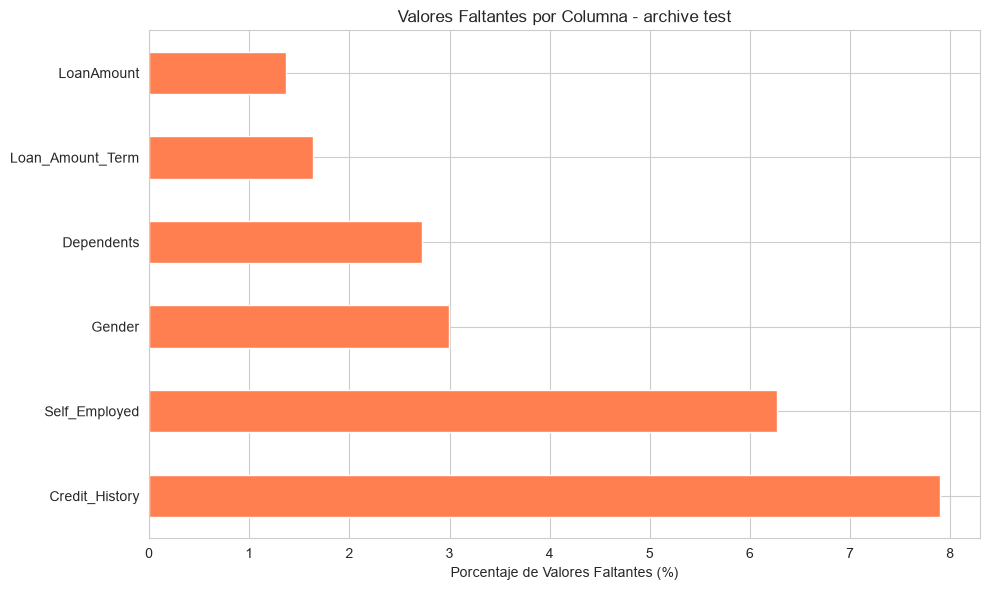

In [4]:
# Valores faltantes
if df.empty:
    print("No hay datos cargados. Se omite el análisis de valores faltantes.")
else:
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_percent})
    missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

    print("Valores faltantes:")
    print(missing_df)

    # Gráfico de valores faltantes
    if len(missing_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        missing_df['Porcentaje'].plot(kind='barh', ax=ax, color='coral')
        ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
        ax.set_title('Valores Faltantes por Columna - archive test')
        plt.tight_layout()
        plt.show()
    else:
        print("No hay valores faltantes en el dataset")

## 5. Análisis por Tipo de Variable

In [5]:
# Separar variables numéricas y categóricas
if df.empty:
    numeric_cols = []
    categorical_cols = []
    print("No hay datos cargados. Se omite el análisis por tipo de variable.")
else:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    print(f"Columnas numéricas ({len(numeric_cols)}): {numeric_cols}")
    print(f"\nColumnas categóricas ({len(categorical_cols)}): {categorical_cols}")

Columnas numéricas (5): ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Columnas categóricas (7): ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## 6. Distribuciones de Variables Numéricas

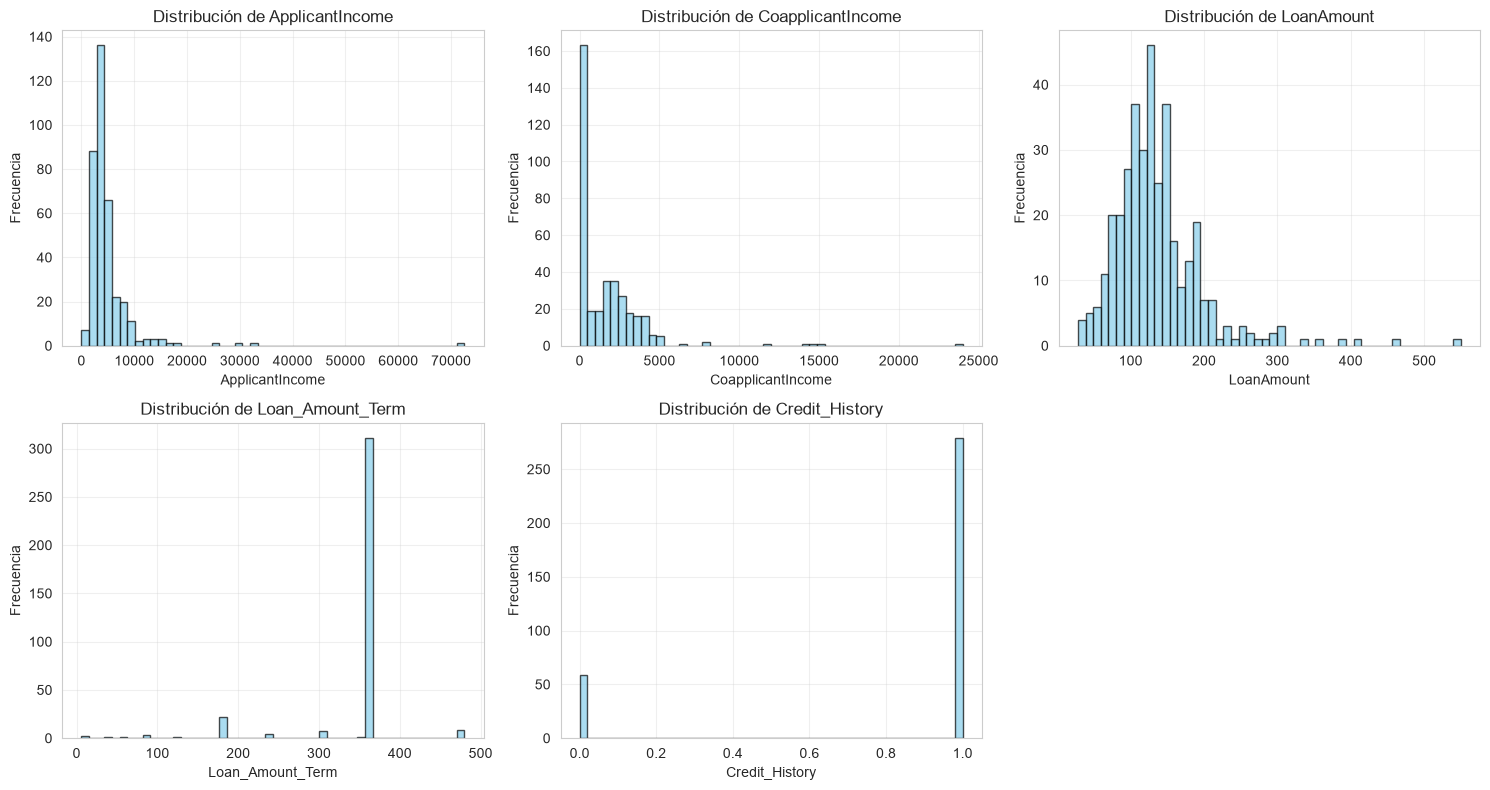

In [6]:
# Histogramas de variables numéricas
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols[:len(axes)]):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(alpha=0.3)
    
    # Ocultar ejes no usados
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 7. Estadísticas de Correlación

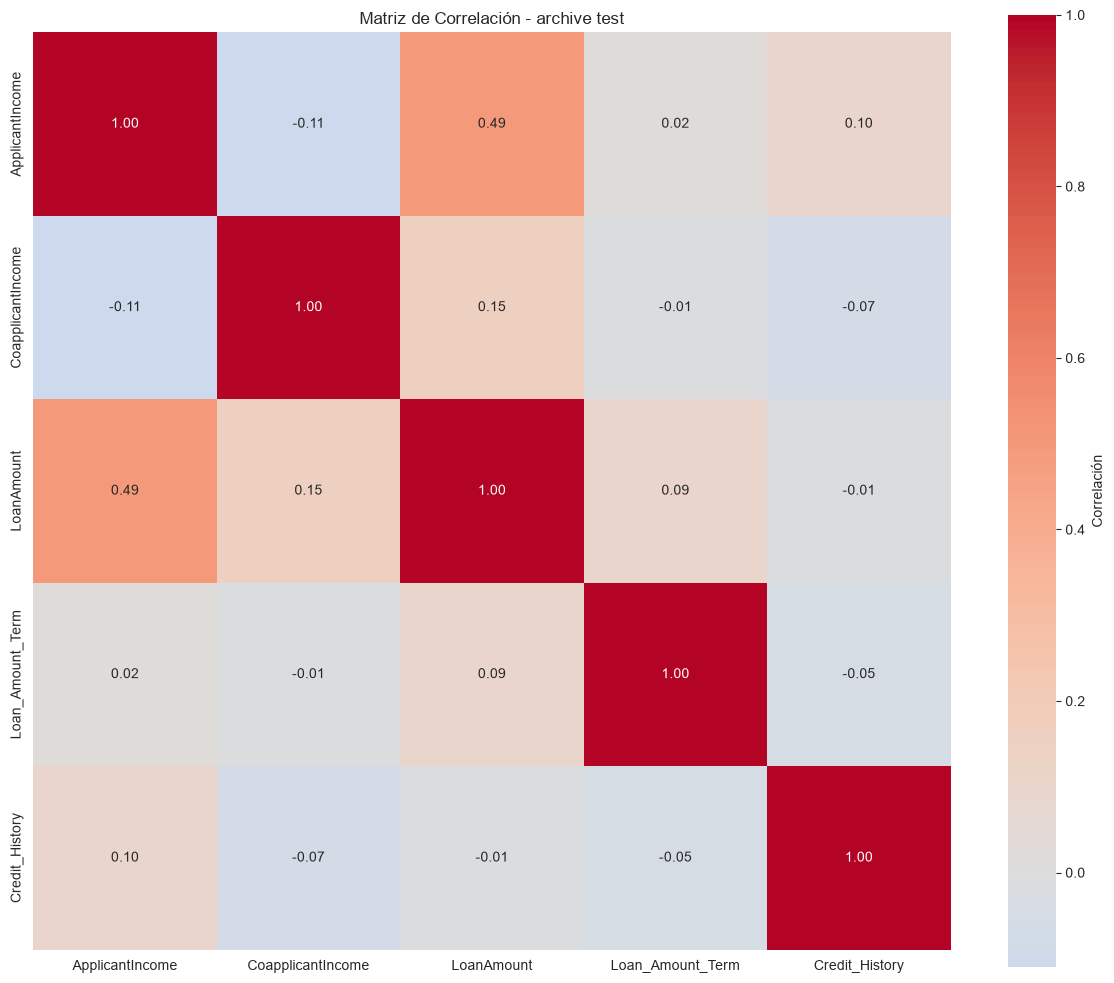

In [7]:
if not df.empty and len(numeric_cols) > 1:
    # Matriz de correlación
    correlation_matrix = df[numeric_cols].corr()
    
    # Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                cbar_kws={'label': 'Correlación'}, square=True)
    plt.title('Matriz de Correlación - archive test')
    plt.tight_layout()
    plt.show()
else:
    print("Insuficientes variables numéricas para matriz de correlación")

## 8. Detección de Outliers

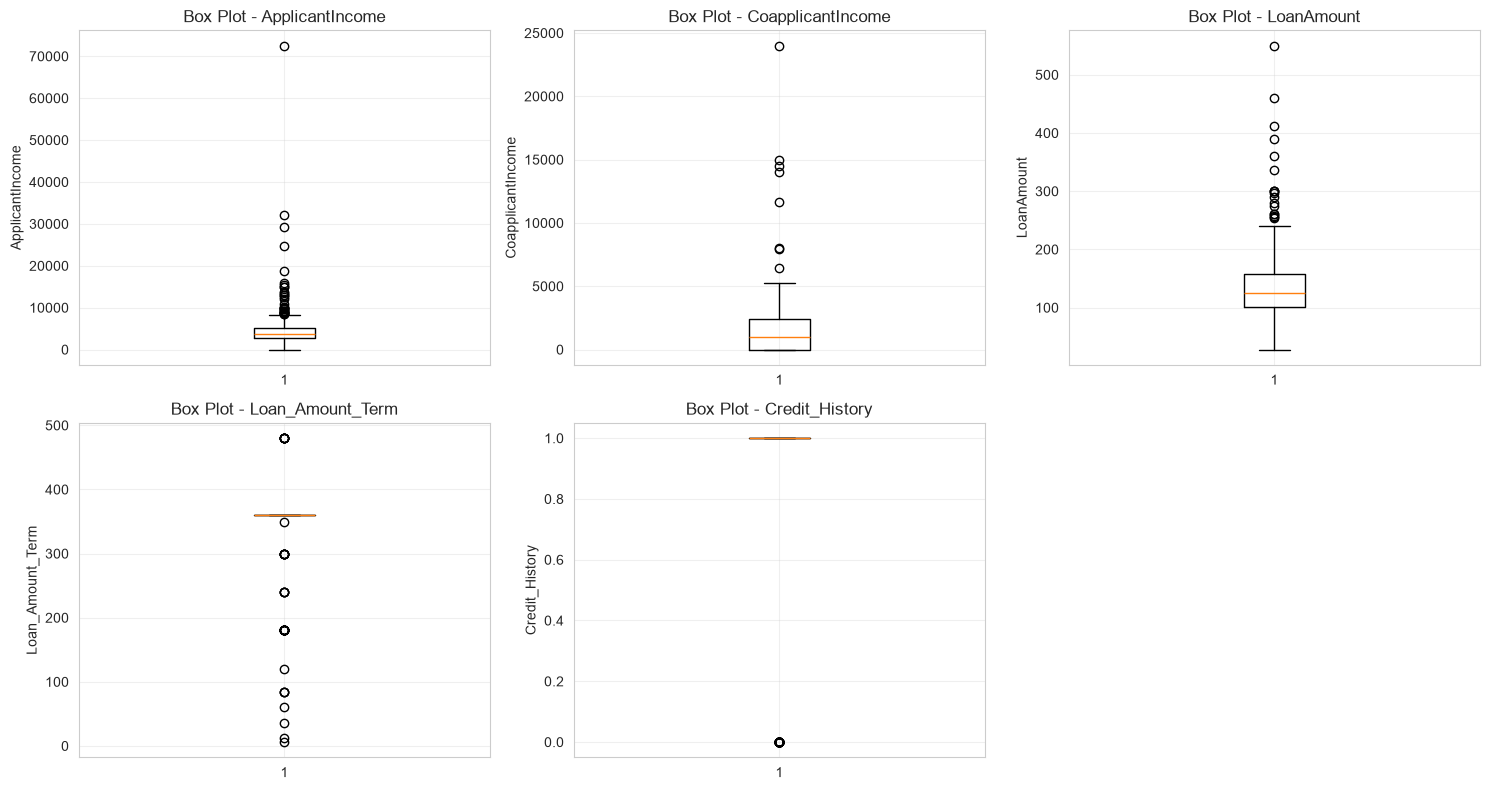

In [8]:
# Box plots para detectar outliers
if numeric_cols:
    numeric_cols_clean = numeric_cols[:6]  # Primeras 6
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols_clean):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Box Plot - {col}')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3)
    
    for idx in range(len(numeric_cols_clean), 6):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 9. Análisis de Variables Categóricas


Loan_ID:
Loan_ID
LP001015    1
LP001022    1
LP001031    1
LP001035    1
LP001051    1
           ..
LP002971    1
LP002975    1
LP002980    1
LP002986    1
LP002989    1
Name: count, Length: 367, dtype: int64


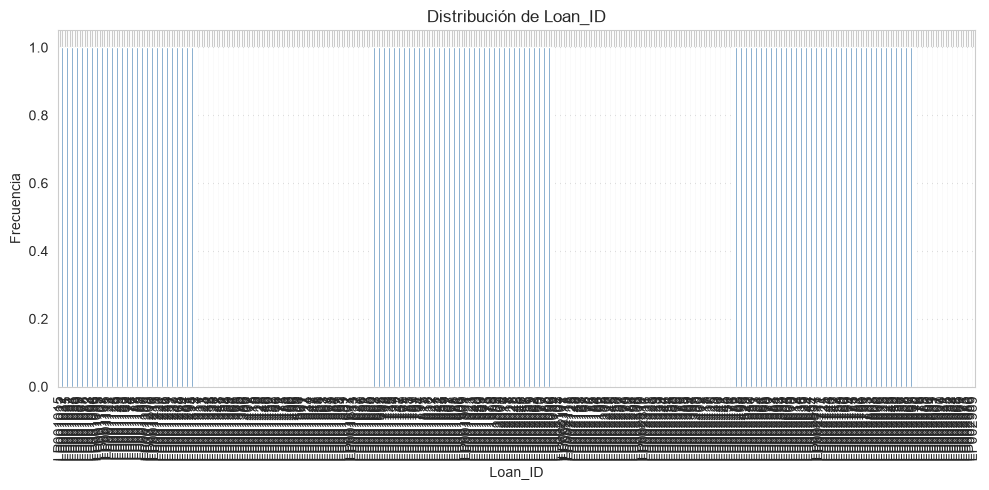


Gender:
Gender
Male      286
Female     70
Name: count, dtype: int64


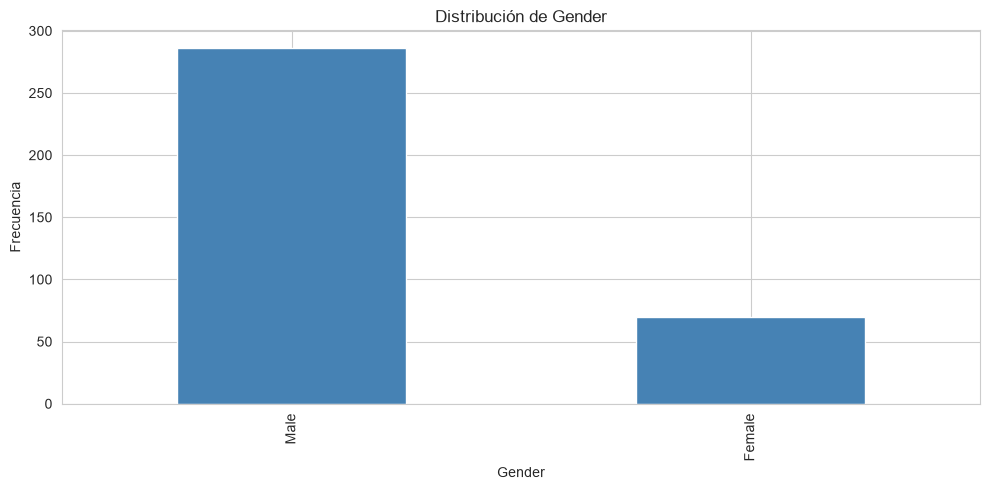


Married:
Married
Yes    233
No     134
Name: count, dtype: int64


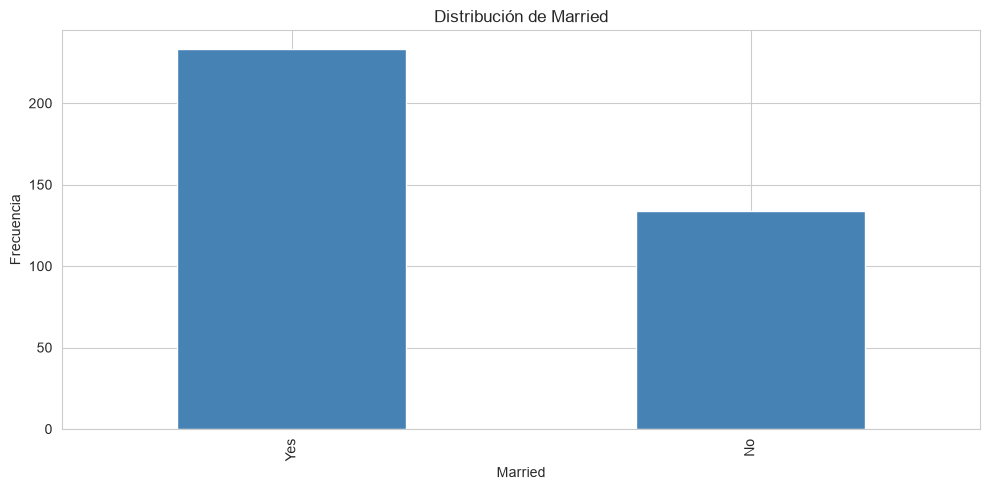


Dependents:
Dependents
0     200
2      59
1      58
3+     40
Name: count, dtype: int64


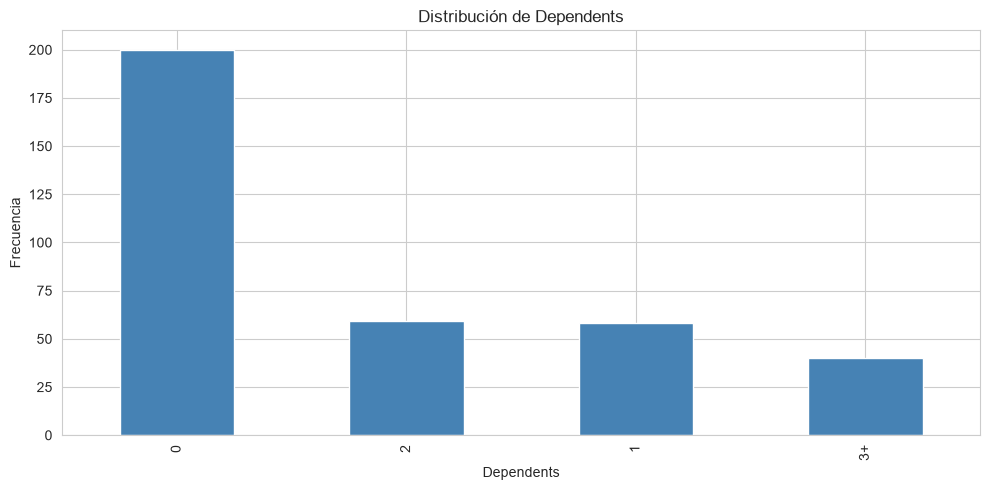

In [9]:
if categorical_cols:
    for col in categorical_cols[:4]:
        print(f"\n{col}:")
        print(df[col].value_counts())
        
        # Gráfico
        fig, ax = plt.subplots(figsize=(10, 5))
        df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

## 10. Resumen de Hallazgos

In [10]:
print("=" * 80)
print("RESUMEN - DATASET test_Y3wMUE5_7gLdaTN.csv")
print("=" * 80)
print(f"\n📊 Tamaño del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n📈 Variables numéricas: {len(numeric_cols)}")
print(f"📂 Variables categóricas: {len(categorical_cols)}")
print(f"\n❌ Filas con valores faltantes: {df.isnull().any(axis=1).sum():,}")
print(f"\n✅ Filas completas: {len(df) - df.isnull().any(axis=1).sum():,}")
print("\n" + "=" * 80)

RESUMEN - DATASET test_Y3wMUE5_7gLdaTN.csv

📊 Tamaño del dataset: 367 filas × 12 columnas

📈 Variables numéricas: 5
📂 Variables categóricas: 7

❌ Filas con valores faltantes: 78

✅ Filas completas: 289

